#Homework_3_Multimodal_LLMs_meme

Ruyi Yang
2026.03


# Modeling: MultiModal AI — Homework 3
**MAS.S60 / 6.S985 • Spring 2026 • MIT**

In this homework, you will explore Vision-Language Models (VLMs) and gain hands-on experience fine-tuning one.

---

## Environment Setup

Go to the top menu:  
Runtime → Change runtime type → Hardware accelerator → Choose "A100"

If you do not have Colab Pro, you can sign up for a free student Colab Pro account here:  
https://colab.research.google.com/signup


# Part 1: Reading & Reflection (20 points)

### Required Reading
[Multimodal Few-Shot Learning with Frozen Language Models](https://arxiv.org/pdf/2106.13884)

[Quality Not Quantity: On the Interaction between Datase Design and Robustness of CLIP
](https://arxiv.org/pdf/2208.05516.pdf)

[Generative AI: Here to stay, but for good?](https://www.sciencedirect.com/science/article/pii/S0160791X2300177X)

---

### Questions
1. What types of multimodal data noise are typically present in multimodal datasets, and how can they negatively impact the performance of a model during training? Can you provide examples of multimodal data points that might be considered noisy? Furthermore, how might we develop estimators capable of distinguishing between noisy and noise-free multimodal data pairs? If you have unlimited fundings to use for data filtering and data cleaning, what would be the ideal way to clean the multimodal dataset?

2. What is the intuition of utilizing frozen large language models as the backbone for multimodal tasks? Which types of encoders would facilitate the integration of diverse information into a format understandable by LLMs? How do these LLMs process and interpret information from different modalities?

3. Ensuring the effectiveness of multimodal foundation models through high-quality instruction tuning is vital. A study detailed at [here](https://arxiv.org/pdf/2402.04333.pdf) introduces a strategy for selecting significant data specifically suited for enhancing instruction tuning for language models. A primary challenge in this approach is determining which data are most crucial for targeted instruction tuning. How can we accurately identify and select the most impactful data for enhancing instruction tuning in multimodal foundation models? Given the complexity of diverse and multimodal information, what strategies can ensure the effectiveness of instruction tuning data for specific tasks?

4. With the advancement of generative AI, distinguishing between AI-generated and human-created content is becoming increasingly challenging. Besides watermarking, which has its limitations, are there other effective methods to differentiate between AI-generated and human-created content across various modalities (text, audio, video, image)? Or is it becoming virtually impossible to make this distinction?

5. For state-of-the-art video generation models like Sora, Yann Lecun mentioned in [here](https://twitter.com/ylecun/status/1758740106955952191) that Sora does not understand the real world and its corresponding physical rules. Do you agree with this view? Can the future development of generative AI systems truly incorporate real-world knowledge, or are they limited in this aspect? Is pursuing generative AI a viable path towards achieving Artificial General Intelligence (AGI)?

Q1
- **Noise & impact**: cross-modal misalignment, weak web labels, and mixed data distributions → models learn spurious correlations, reducing robustness and zero-shot generalization
- **Handling**: use pretrained alignment models (e.g., CLIP scoring) + iterative filtering; ideal setup = human-in-the-loop + distribution-aware curation (avoid naive data mixing)   


Q2
- **Intuition**: LLMs already encode rich knowledge and reasoning; multimodal learning reduces to mapping other modalities into the token embedding space
- **Mechanism**: modality encoders (e.g., vision → embedding sequence) + transformer processes interleaved embeddings in a modality-agnostic way



Q3
- **Core principle**: data quality and distribution matter more than scale; different datasets induce different robustness properties
- **Strategy**: select data based on alignment quality, task relevance, and expected training impact (instead of naive large-scale crawling)  


Q4
- **Trend**: increasingly difficult (near impossible) as generative models produce highly realistic multimodal outputs
- **Alternatives**: provenance tracking, metadata, and model fingerprints—but none are fully reliable  

Q5
- **View**: current models are statistical pattern learners, not grounded in physical or causal understanding
- **Outlook**: integrating world models may help, but generative AI alone is insufficient for AGI (requires grounding + reasoning)

# Part 2: Testing and Fine-tuning VLMs (100 points)

# Problem 1: GPU Verification and Library Installation

Run the following code cell to verify that your environment is correctly configured.

This step ensures that **PyTorch** and **CUDA** can access the GPU.  
When the setup is correct, a **secret word** will appear in the output.

---

### In Your PDF Submission

Include:
- A **screenshot** or **code snippet** showing the printed GPU information.  
- The **secret word** displayed by your verification cell.

---

In [ ]:
# !pip install transformers accelerate bitsandbytes pillow torch -q

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t = torch.randn(2, 3, device=device)
KEY = 42
cipher_bytes = [99, 10, 102, 101, 124, 111, 10, 103, 103, 107, 99]

if t.is_cuda:
    cipher = torch.tensor(cipher_bytes, dtype=torch.uint8, device=device)
    decoded = torch.bitwise_xor(cipher, KEY)
    torch.cuda.synchronize()
    secret = bytes(decoded.tolist()).decode("ascii")
    print("SECRET_WORD:", secret)
else:
    print("SECRET_WORD: (not on GPU)")

PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device count: 1
GPU name: NVIDIA A100-SXM4-40GB
SECRET_WORD: I LOVE MMAI


In [ ]:
# import library

import os
import pandas as pd
import torch
import transformers
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.utils.data import random_split
from transformers import BertTokenizer, BertModel

import matplotlib.pyplot as plt
from tqdm import tqdm
import time
from datasets import load_dataset

import shutil, zipfile
from pathlib import Path
import json
from IPython.display import display

# Problem 2: Prepare Your Dataset (20 points)

## **PLEASE READ THIS ENTIRE SECTION BEFORE PROCEDING**

For Problem 2, you will **use the dataset you have collected from Homework 1 and Homework 2 or a completely new one if you prefer** to fine-tune a Vision-Language Model (VLM).

Even if your original data isn't image-based (e.g. it's audio, time-series, or text), you should find a way to **visualize it** meaningfully. The dataset you prepare will serve as the foundation for model fine-tuning in later steps.

---

### How to Convert Your Project Data Into Images

**If your project is not originally image-based, consider these ideas to generate visual input:**

| Data Type                    | Visual Representation Example                          |
|-----------------------------|---------------------------------------------------------|
| Time-series / sensor data   | Line plots or multi-panel charts (with axis labels)     |
| Audio / Music / Physiology  | Spectrograms or waveform plots                         |
| 3d data (point clouds, CAD) | Rendering/splicing into 2D images

You are encouraged to be **creative and domain-specific** in your visualizations.

**You will need to explore ways to convert your data into images if it does not already consist of this modality. Research on your own and come up with the needed code to do so. If you are still stuck on figuring this out, please reach out to a TA for help!**

### Download Example Training Data

The next block of code will download an example dataset and create a folder named `mmai-data/`.  
Inside this folder, you will find:

```
mmai-data/
├── images/
│   ├── 1.jpg
│   └── 2.jpg
└── data.jsonl
```

The file `data.jsonl` contains your training annotations.  
Each line represents one training example with the following fields:

```json
{
  "image": "images/1.jpg",
  "question": "List objects you see.",
  "answer": "cat, sofa, blanket, remote, cushion"
}
```

---

### Your Task

Now, prepare your own dataset following the same structure as the example.


Example structure:

```
mmai-data/
├── images/
│   ├── image_01.jpg
│   ├── image_02.jpg
│   ├── ...
└── data.jsonl
```

As part of this task. You should split the data into a train and test split. **The test split should consist of the images of data that you will not use in training.**


In [ ]:
hf = load_dataset("Emmaruyi/met-meme-filtered")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/192M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/23.0M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2711 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/338 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/340 [00:00<?, ? examples/s]

In [ ]:
#@title I did this locally
# ============================================================
# Build mmai-data/ from Emmaruyi/met-meme-filtered
# Uses the dataset's own train/test splits directly.
# I did this locally
# ============================================================

# import os, json
# from pathlib import Path


# TRAIN_SAMPLES = 120   # how many to take from the HF train split
# TEST_SAMPLES  = 30    # how many to take from the HF test split
# OUTPUT_ROOT   = Path("mmai-data")

# INTENTION_MAP = {
#     1: "Interactive",
#     2: "Expressive",
#     3: "Entertaining",
#     4: "Offensive",
#     5: "Other",
# }
# QUESTION = (
#     "What is the communicative intention of this meme? "
#     "Answer with exactly one word from: Interactive, Expressive, Entertaining, Offensive, Other."
# )

# # hf is already loaded above (load_dataset("Emmaruyi/met-meme-filtered"))
# train_split = list(hf["train"])[:TRAIN_SAMPLES]
# test_split  = list(hf["test"])[:TEST_SAMPLES]

# print(f"Using {len(train_split)} train samples, {len(test_split)} test samples")

# def write_split(samples, split_name: str):
#     img_dir   = OUTPUT_ROOT / split_name / "images"
#     jsonl_path = OUTPUT_ROOT / split_name / "data.jsonl"
#     img_dir.mkdir(parents=True, exist_ok=True)

#     records = []
#     for i, ex in enumerate(samples):
#         fname = f"{i:04d}.jpg"
#         ex["image"].convert("RGB").save(img_dir / fname, format="JPEG")
#         records.append({
#             "image":    f"images/{fname}",
#             "question": QUESTION,
#             "answer":   INTENTION_MAP.get(ex["intention_num"], "Other"),
#         })

#     with open(jsonl_path, "w") as f:
#         for r in records:
#             f.write(json.dumps(r) + "\n")

#     print(f"  [{split_name}] {len(records)} records → {jsonl_path}")

# write_split(train_split, "train")
# write_split(test_split,  "test")

# # Preview
# print("\nSample records (train):")
# with open(OUTPUT_ROOT / "train" / "data.jsonl") as f:
#     for line in list(f)[:3]:
#         print(" ", line.strip())


In [ ]:

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Upload your dataset as a zip file to Google Drive, then
# replace the URL below with your own Google Drive share link.
#
# Your zip should unpack into a folder called mmai-data/ with:
#   mmai-data/
#   ├── images/
#   │   ├── image_01.jpg
#   │   ├── ...
#   │   └── image_16.jpg
#   └── data.jsonl
#
# Each line in data.jsonl should be a JSON object with three
# fields: "image", "question", and "answer". For example:
#
#   {"image": "images/1.jpg", "question": "List objects you see.", "answer": "cat, sofa, blanket, remote, cushion, tail, paw"}
#   {"image": "images/2.jpg", "question": "List objects you see.", "answer": "car, truck, road, bridge, exit sign, lamppost, building, sky"}
#
URL = "https://drive.google.com/file/d/12TeE3FMTgXlJ42N64ohgJ1W1DS17RX5U/view?usp=sharing"
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

DATA_DIR = Path("/content/")
DATA_DIR.mkdir(parents=True, exist_ok=True)

!pip -q install gdown
import gdown

print("Downloading…")
downloaded_path = gdown.download(URL, output=None, quiet=False, fuzzy=True)
if not downloaded_path or not os.path.exists(downloaded_path):
    raise RuntimeError("Download failed. Check the URL or your Drive permissions.")

src = Path(downloaded_path)
dst = DATA_DIR / src.name
if src.resolve() != dst.resolve():
    shutil.move(str(src), str(dst))

print(f"\nFile saved to: {dst}")

if zipfile.is_zipfile(dst):
    extract_dir = DATA_DIR / dst.stem
    extract_dir.mkdir(exist_ok=True)
    print(f"Unzipping into: {extract_dir}")
    with zipfile.ZipFile(dst, "r") as zf:
        zf.extractall(extract_dir)
    print("Unzip complete.")

if dst.suffix.lower() == ".jsonl":
    print("\nSet this in your training cell:")
    print(f'DATA_JSONL = "{dst}"')

Downloading…


Downloading...
From: https://drive.google.com/uc?id=12TeE3FMTgXlJ42N64ohgJ1W1DS17RX5U
To: /content/mmai-data.zip
100%|██████████| 1.55M/1.55M [00:00<00:00, 147MB/s]


File saved to: /content/mmai-data.zip
Unzipping into: /content/mmai-data
Unzip complete.


**Questions to Answer:**

*   Explain some possible issues with converting non-image data into images (even if you did not have to do so, discuss what could be some issues).

*   What are some possible issues with using visual representations of your data. Discuss some drawbacks of doing this (if you did not have to do the conversion as your data was already in the form of images, then discuss the drawbacks of converting those images to another modality like text, audio, etc.).


* Discuss the strategy you decided on how to split your data into train/test splits. Why did you settle on this? Were any other alternative splits considered?


**Answer:**

I don't have converstion

Q1
- Temporal or structural information (e.g. rhythm in audio) may be lost or distorted in visual encoding
- Arbitrary visualization choices (scale, color map, resolution) can introduce unintended bias

Q2.
- Models must learn to re-decode the visualization rather than the underlying signal, adding unnecessary complexity
- Fine-grained patterns in the original modality (e.g. subtle frequency changes in audio) may be invisible at typical image resolutions

Q3
- I split it in previous step (hw2) using stratified random sampling


# Problem 3: Baseline Inference (10 points)

# Problem 3.1 Load the Model

Begin by running the following code to **load the base model** into memory. This step is required before training or making predictions.


In [ ]:
import io, requests, torch
from PIL import Image, UnidentifiedImageError
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

# 1) Load model + processor (processor handles BOTH text + vision)
processor = AutoProcessor.from_pretrained(model_id)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)
print("Model and tokenizer loaded successfully.")

preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Model and tokenizer loaded successfully.


# Problem 3.2: Run the Model on Your 4 Held-Out Images

In this step, you will use the **pre-trained** `Qwen2.5-VL-3B-Instruct` model (no fine-tuning yet) to answer questions about the **held-out images** that were **not used in training**. You will then compare the model’s predictions with the ground-truth labels and reflect on its performance.

---

## Instructions

1. **Select four held-out images**  
   Choose four test images from your dataset that were excluded from training and prompt development.

2. **Ask a consistent question**  
   Use the same question for all images, or a small set of label-aligned questions.

3. **Run the model**  
   Use the provided code cell to run inference with the pre-trained model.  

4. **Record your results**  
   For each image, collect the model’s raw output and compare it to the ground-truth label(s). If there are too many images, then show a few examples.

---

## Reflection (5–8 sentences)

After running the model on your four images, briefly discuss:
- **What worked?**  
  Which prompts or parameter settings produced better results?
- **What failed?**  
  Were there recurring failure modes (e.g., hallucinations, vague answers)?
- **Patterns in mistakes**  
  Did errors correlate with certain categories, lighting conditions, or question phrasing?

---

## Suggested Output Format

| Image ID/URL | Question | Model Output | Ground Truth | Result |
|---------------|-----------|---------------|---------------|---------|
| `img_001.jpg` | “What objects are visible?” | cat, sofa | cat, sofa | Correct |
| `img_002.jpg` | “What objects are visible?” | road, truck, sign | road, car, sign | Incorrect |

In [ ]:

# ============================================================
TEST_JSONL: str = "/content/mmai-data/test/data.jsonl"
TEST_BASE_DIR: str = "/content/mmai-data/test"
TEST_QUESTION: str = "What is the communicative intention of this meme? Answer with exactly one word from: Interactive, Expressive, Entertaining, Offensive, Other."
MAX_NEW_TOKENS: int = 128
N_SAMPLES: int = 4
# ============================================================

# Load test records
with open(TEST_JSONL) as f:
    test_records = [json.loads(l) for l in f if l.strip()][:N_SAMPLES]

results = []
for i, record in enumerate(test_records):
    img_path = os.path.join(TEST_BASE_DIR, record["image"])
    loaded_img = Image.open(img_path).convert("RGB")
    ground_truth = record["answer"]

    messages = [{"role": "user", "content": [
        {"type": "image", "image": loaded_img},
        {"type": "text", "text": TEST_QUESTION}
    ]}]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[loaded_img], return_tensors="pt").to(model.device)

    with torch.no_grad():
        out_ids = model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)

    output_text = processor.batch_decode(out_ids, skip_special_tokens=True)[0].strip().split()[-1]
    correct = output_text == ground_truth
    results.append((record["image"], output_text, ground_truth, "Correct" if correct else "Incorrect"))
    print(f"[{i+1:02d}] {record['image']} | Pred: {output_text} | GT: {ground_truth} | {'correct' if correct else 'wrong'}")


[01] images/0000.jpg | Pred: Expressive | GT: Entertaining | wrong
[02] images/0001.jpg | Pred: Expressive | GT: Expressive | correct
[03] images/0002.jpg | Pred: Expressive | GT: Entertaining | wrong
[04] images/0003.jpg | Pred: Expressive | GT: Expressive | correct


In [ ]:
import io
import os
import requests
import torch
from typing import Optional, Dict, Any
from PIL import Image, UnidentifiedImageError
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration


# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# IMAGE_URL: str = "http://images.cocodataset.org/val2017/000000039769.jpg"
IMAGE_URL: str = "https://www.dropbox.com/scl/fi/pd0n9508q579pvyfujskr/meme_sample_image.jpg?rlkey=zq4uonuuv5iv4t2v2ri28meed&raw=1"
QUESTION: str = "What is the communicative intention of this meme? Answer with exactly one word from: Interactive, Expressive, Entertaining, Offensive, Other."

# SYSTEM_PROMPT: str = "You are a helpful assistant."
# variation 1
# SYSTEM_PROMPT = "You are a meme analyst. Examples: a meme asking for likes → Interactive; a meme venting frustration → Expressive; a funny joke meme → Entertaining; a meme mocking a group → Offensive."

# Adding examples (few-shot prompting)
# SYSTEM_PROMPT = (
#     "You are a meme intention classifier. Here are some examples:\n"
#     "- A meme saying 'Tag a friend who does this' → Interactive\n"
#     "- A meme showing frustration about Monday mornings → Expressive\n"
#     "- A meme with a funny punchline about cats → Entertaining\n"
#     "- A meme mocking a specific ethnic group → Offensive\n"
#     "- A meme that doesn't fit the above → Other\n"
#     "Classify the given meme accordingly."
# )
# # Restricting answer formats (e.g., "Answer with one word")
# SYSTEM_PROMPT = (
#     "You are a meme intention classifier. "
#     "Respond with exactly one word from: Interactive, Expressive, Entertaining, Offensive, Other. "
#     "Do not include punctuation, explanation, or any other text."
# )

# # Asking for explanations or step-by-step reasoning
SYSTEM_PROMPT = (
    "You are a meme analyst. When classifying a meme's communicative intention, "
    "first describe what you see in the image, "
    "then describe the caption in the image, "
    "then identify the tone and target audience, "
    "then output the label on the last line as: Label: <one of Interactive, Expressive, Entertaining, Offensive, Other>."
)


MAX_NEW_TOKENS: int = 128
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG
DO_SAMPLE: bool = False           # set True for non-greedy decoding
TEMPERATURE: float = 0.7          # used only if DO_SAMPLE=True
TOP_P: float = 0.9                # used only if DO_SAMPLE=True
MODEL_ID: str = "Qwen/Qwen2.5-VL-3B-Instruct"
FORCE_CPU: bool = False           # force CPU even if CUDA is available
DTYPE_IF_GPU = torch.bfloat16     # prefer bfloat16 on recent GPUs/Colab
DTYPE_IF_CPU = torch.float32

def get_device_and_dtype() -> tuple[torch.device, torch.dtype, Optional[Dict[str, Any]]]:
    """Choose device/dtype and (optionally) a device_map for accelerate-style placement."""
    use_cuda = torch.cuda.is_available() and not FORCE_CPU
    device = torch.device("cuda") if use_cuda else torch.device("cpu")
    torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
    device_map = "auto" if use_cuda else None
    return device, torch_dtype, device_map


def load_image_from_url(url: str) -> Image.Image:
    """Fetch image from URL and return a RGB PIL.Image with robust fallback."""
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    try:
        return Image.open(io.BytesIO(resp.content)).convert("RGB")
    except UnidentifiedImageError:
        # Fallback: write to disk then reopen (sometimes fixes truncated headers)
        tmp_path = "temp_image.jpg"
        with open(tmp_path, "wb") as f:
            f.write(resp.content)
        img = Image.open(tmp_path).convert("RGB")
        try:
            os.remove(tmp_path)
        except Exception:
            pass
        return img


def build_chat_messages(image: Image.Image, question: str) -> list[dict]:
    """Create a single-turn, image+text chat for Qwen-VL processors."""
    return [
        {
            "role": "system",
            "content": [
                {"type": "text", "text": SYSTEM_PROMPT}
            ],
        },
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": question},
            ],
        }
    ]


def main() -> None:
    device, torch_dtype, device_map = get_device_and_dtype()

    # 1) Load model + processor
    processor = AutoProcessor.from_pretrained(MODEL_ID)
    model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
        MODEL_ID,
        torch_dtype=torch_dtype,
        device_map=device_map,
    )
    print("Model and processor loaded successfully.")

    # 2) Load image
    image = load_image_from_url(IMAGE_URL)

    # 3) Build chat
    messages = build_chat_messages(image, QUESTION)

    # 4) Apply chat template and preprocess
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[image], return_tensors="pt")

    # 5) Move to the right device
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # 6) Generate
    gen_kwargs = dict(max_new_tokens=MAX_NEW_TOKENS)
    if DO_SAMPLE:
        gen_kwargs.update(dict(do_sample=True, temperature=TEMPERATURE, top_p=TOP_P))

    with torch.no_grad():
        gen_ids = model.generate(**inputs, **gen_kwargs)

    # 7) Decode
    out = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
    print("\n=== MODEL OUTPUT ===")
    print(out)


if __name__ == "__main__":
    main()


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Model and processor loaded successfully.

=== MODEL OUTPUT ===
system
You are a meme analyst. When classifying a meme's communicative intention, first describe what you see in the image, then describe the caption in the image, then identify the tone and target audience, then output the label on the last line as: Label: <one of Interactive, Expressive, Entertaining, Offensive, Other>.
user
What is the communicative intention of this meme? Answer with exactly one word from: Interactive, Expressive, Entertaining, Offensive, Other.
assistant
Expressive


# Problem 4: Prompt Engineering (15 points)

In this step, you'll experiment with **prompt design** to explore how different instructions influence model performance.

---

### Instructions

1. Modify the **`SYSTEM_PROMPT`** variable inside the **CHANGE ME** section of the code above.  
2. Re-run the corresponding code cell to observe how the model's responses change.  
3. Test various prompt strategies, such as:
   - Adding **examples** (few-shot prompting)
   - Restricting **answer formats** (e.g., "Answer with one word")
   - Asking for **explanations** or **step-by-step reasoning**
4. Compare your new results with the baseline output.

---

### Reflection

In your write-up, discuss:
- Which types of prompt changes improved performance?  
- Did adding context or structure help the model reason more effectively?  
- Were there any surprising or inconsistent results?


![meme_sample_image.jpg](https://www.dropbox.com/scl/fi/pd0n9508q579pvyfujskr/meme_sample_image.jpg?rlkey=zq4uonuuv5iv4t2v2ri28meed&raw=1)

Grondtruth: Expressive

output:

sample
```
system
You are a helpful assistant.
user
What is the communicative intention of this meme? Answer with exactly one word from: Interactive, Expressive, Entertaining, Offensive, Other.
assistant
Expressive
```


Adding examples (few-shot prompting)
```
system
You are a meme intention classifier. Here are some examples:
- A meme saying 'Tag a friend who does this' → Interactive
- A meme showing frustration about Monday mornings → Expressive
- A meme with a funny punchline about cats → Entertaining
- A meme mocking a specific ethnic group → Offensive
- A meme that doesn't fit the above → Other
Classify the given meme accordingly.
user
What is the communicative intention of this meme? Answer with exactly one word from: Interactive, Expressive, Entertaining, Offensive, Other.
assistant
Entertaining
```

Restricting answer formats (e.g., "Answer with one word")
```
system
You are a meme intention classifier. Respond with exactly one word from: Interactive, Expressive, Entertaining, Offensive, Other. Do not include punctuation, explanation, or any other text.
user
What is the communicative intention of this meme? Answer with exactly one word from: Interactive, Expressive, Entertaining, Offensive, Other.
assistant
Expressive
```



Asking for explanations or step-by-step reasoning
```
system
You are a meme analyst. When classifying a meme's communicative intention, first describe what you see in the image, then describe the caption in the image, then identify the tone and target audience, then output the label on the last line as: Label: <one of Interactive, Expressive, Entertaining, Offensive, Other>.
user
What is the communicative intention of this meme? Answer with exactly one word from: Interactive, Expressive, Entertaining, Offensive, Other.
assistant
Expressive
```









Reflection

- The baseline and format-restriction prompts both correctly predicted Expressive, suggesting that clear, concise instructions are sufficient for this task.
- The few-shot prompt surprisingly produced Entertaining (incorrect), indicating that example-based prompting can mislead the model when the examples don't closely match the input meme's style.
- The chain-of-thought prompt also returned Expressive (correct), and the step-by-step reasoning likely helped the model ground its prediction in visual and textual evidence rather than pattern-matching.
- Overall, adding more structure did not consistently improve performance — the simplest prompt matched the most complex one. The few-shot result was the most unexpected, as it is generally expected to help but here introduced confusion.


# Problem 5: LoRA Fine-Tuning (20 points)

In this step, you'll fine-tune a **Vision-Language Model (VLM)** using **LoRA (Low-Rank Adaptation)** on your dataset.  
This exercise will help you understand how different hyperparameters influence performance, GPU memory usage, and output quality.

### Instructions

Run the code block below.  
If you followed the **`mmai-data`** example, the script should automatically detect and load your training dataset.

### Adjust and experiment with

- **Number of epochs** (`NUM_EPOCHS`)
- **Learning rate** (`LR`)
- **Batch size per device** (`BSZ_PER_DEV`)
- **Gradient accumulation steps** (`GRAD_ACCUM`)
- **Evaluation split ratio** (`EVAL_SPLIT`)
- **Random seed** (`SEED`)
- **Sequence length** (`MAX_SEQ_LEN`)
- **Image resolution** (`SHORTEST_EDGE`)
- **LoRA rank** (`LORA_R`)
- **LoRA alpha** (`LORA_ALPHA`)
- **LoRA dropout** (`LORA_DROPOUT`)
- **LoRA target modules** (`LORA_TARGET`)

```
- LORA_R: Controls the expressive power of LoRA (the higher the rank, the more variations the model can learn).

- LORA_ALPHA: Controls the overall intensity of LoRA updates (the higher the alpha, the stronger the impact on the original model).

- LORA_DROPOUT: Introduces random dropout within the LoRA layers to prevent overfitting (a higher value results in a more conservative approach).

- LORA_TARGET: Specifies which model layers LoRA is applied to (determining which parts of the model are fine-tuned).
```

---

```python
# ============================================================
# ######################## CHANGE ME #########################
# ============================================================

# (Modify the parameters below in the Colab cell)

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================
```

### Q&A

**Q:** What should I do if I encounter an out-of-memory issue?  
**A:** Your image might be too large. Try resizing it by adding the following line back into your code and experiment with different pixel values:

```python
img.thumbnail((128, 128))  # NOTE: If you run into an out-of-memory error, try adding this line back.
```


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Set image shortest_edge to 288, longest_edge to 1152


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 1,843,200 || all params: 3,756,466,176 || trainable%: 0.0491


Step,Training Loss
1,8.518922
2,8.507822
3,8.630420
4,8.450886
5,8.709011
6,8.308069
7,8.370804
8,8.496065
9,8.226643
10,8.144778


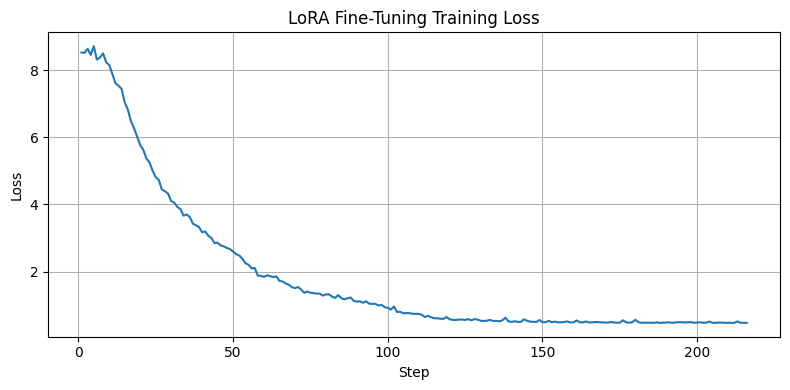

Training complete. LoRA adapters saved to: /content/qwen2_5_vl_lora_fp16_t4


In [ ]:
from re import L
# ==== Qwen2.5-VL-3B-Instruct • FP16 LoRA ====

from IPython.display import display, HTML
import os, io, json, requests, torch, random, hashlib
from dataclasses import dataclass
from typing import Any, Dict, List
from PIL import Image
from torch.utils.data import Dataset
import torch.nn as nn
from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model

# Environment hygiene
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:64"

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Training hyperparameters
NUM_EPOCHS: int  = 2
LR: float        = 1e-4
BSZ_PER_DEV: int = 1
GRAD_ACCUM: int  = 1
EVAL_SPLIT: float = 0.1
SEED: int        = 42

# Collator / sequence shaping
MAX_SEQ_LEN: int = 512   # try 384 if VRAM is tight

# Image preprocessing
SHORTEST_EDGE: int = 288  # smaller saves VRAM
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================


# SYSTEM CONFIG
# Paths
DATA_JSONL: str  = "/content/mmai-data/train/data.jsonl"
OUTPUT_DIR: str  = "/content/qwen2_5_vl_lora_fp16_t4"

MODEL_ID: str     = "Qwen/Qwen2.5-VL-3B-Instruct"
CACHE_DIR: str    = "/content/cache_images"
IMAGE_TIMEOUT: int = 15

# LoRA configuration (attention-only keeps memory low)
LORA_R: int          = 4
LORA_ALPHA: int      = 8
LORA_DROPOUT: float  = 0.05
LORA_TARGET: list[str] = ["q_proj", "k_proj", "v_proj", "o_proj"]
# LORA_TARGET: list[str] = ["q_proj", "k_proj"]

# Device / dtype policy
FORCE_CPU: bool   = False
DTYPE_IF_GPU      = torch.float16
DTYPE_IF_CPU      = torch.float32


# Repro and cache dirs
torch.manual_seed(SEED); random.seed(SEED)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)


# --------------------
# Demo data (create if missing)
# --------------------
def _ensure_sample_data(path: str):
    # Ensure parent directory exists
    os.makedirs(os.path.dirname(path), exist_ok=True)

    if os.path.exists(path):
      display(HTML(
          "<div style='color:white; background-color:#2e7d32; padding:10px; border-radius:6px;'>"
          "<strong>Using custom training data:</strong> "
          f"Loaded dataset from <code>{path}</code>. "
          "Proceeding with user-provided images and JSONL file."
          "</div>"
      ))
      return

    demo = [
        {
            "image": "http://images.cocodataset.org/val2017/000000039769.jpg",
            "question": "What is the communicative intention of this meme? Answer with exactly one word from: Interactive, Expressive, Entertaining, Offensive, Other.",
            "answer": "Entertaining"
        },
        {
            "image": "http://images.cocodataset.org/val2017/000000001532.jpg",
            "question": "What is the communicative intention of this meme? Answer with exactly one word from: Interactive, Expressive, Entertaining, Offensive, Other.",
            "answer": "Expressive"
        },
    ]
    with open(path, "w") as f:
        for r in demo: f.write(json.dumps(r) + "\n")

    # Print a red warning box (works in Colab/Jupyter)
    display(HTML(
        "<div style='color:white; background-color:#b71c1c; padding:10px; border-radius:6px;'>"
        "<strong>Warning:</strong> No dataset found — using built-in <code>sample data</code> (2 demo images). "
        "Please replace with your own dataset of at least 20 images for training."
        "</div>"
    ))

_ensure_sample_data(DATA_JSONL)


# --------------------
# Minimal JSONL dataset
# --------------------
class JsonlVisionLangDataset(Dataset):
    def __init__(self, jsonl_path: str):
        self.samples: list[dict] = []
        with open(jsonl_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line: continue
                ex = json.loads(line)
                if {"image","question","answer"} - set(ex.keys()): continue
                self.samples.append(ex)
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx: int) -> Dict[str, Any]: return self.samples[idx]

full_ds = JsonlVisionLangDataset(DATA_JSONL)

# Manual split
n = len(full_ds); n_val = max(1, int(n * EVAL_SPLIT))
idx = list(range(n)); random.shuffle(idx)
val_idx = set(idx[:n_val])
train_data = [full_ds[i] for i in range(n) if i not in val_idx]
val_data   = [full_ds[i] for i in range(n) if i in val_idx]

class ListDataset(Dataset):
    def __init__(self, data_list): self.data_list = data_list
    def __len__(self): return len(self.data_list)
    def __getitem__(self, i): return self.data_list[i]


# --------------------
# Cache images locally (avoid network hiccups)
# --------------------
BASE_DIR = os.path.dirname(DATA_JSONL)

def cache_image(url_or_path: str) -> str:
    # Remote URL: download and cache
    if url_or_path.startswith(("http://", "https://")):
        h = hashlib.md5(url_or_path.encode()).hexdigest()
        local = os.path.join(CACHE_DIR, f"{h}.jpg")
        if not os.path.exists(local):
            r = requests.get(url_or_path, timeout=IMAGE_TIMEOUT); r.raise_for_status()
            with open(local, "wb") as f: f.write(r.content)
        return local

    # Local path: make absolute relative to the JSONL file
    candidate = url_or_path
    if not os.path.isabs(candidate):
        candidate = os.path.join(BASE_DIR, url_or_path)

    if not os.path.exists(candidate):
        raise FileNotFoundError(
            f"Image not found: {candidate} (from '{url_or_path}'). "
            f"Expected under {BASE_DIR}/"
        )
    return candidate


for ex in train_data: ex["image"] = cache_image(ex["image"])
for ex in val_data:   ex["image"] = cache_image(ex["image"])

train_ds = ListDataset(train_data)
val_ds   = ListDataset(val_data)


# --------------------
# Image loader
# --------------------
def load_image(img_path: str) -> Image.Image:
    img = Image.open(img_path).convert("RGB")
    img.thumbnail((128, 128))  # NOTE: if you run into out of memory error, try adding this line back
    return img


# --------------------
# Processor + Model (FP16 on GPU, FP32 on CPU)
# --------------------
use_cuda = torch.cuda.is_available() and not FORCE_CPU
torch_dtype = DTYPE_IF_GPU if use_cuda else DTYPE_IF_CPU
# device_map = "auto" if use_cuda else None
device_map = "cuda:0" if use_cuda else None

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch_dtype,            # transformers v5 uses 'dtype'
    device_map=device_map,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)

# Smaller images to save VRAM
try:
    if hasattr(processor, "image_processor") and hasattr(processor.image_processor, "size"):
        processor.image_processor.size = {
            "shortest_edge": int(SHORTEST_EDGE),
            "longest_edge": int(SHORTEST_EDGE * 4),
        }
        print(f"Set image shortest_edge to {SHORTEST_EDGE}, longest_edge to {SHORTEST_EDGE * 4}")
except Exception as e:
    print("Skip image size tweak:", e)

# Enable gradient checkpointing; avoid k-bit prep (saves VRAM)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()
model.config.use_cache = False


# --------------------
# LoRA (attention-only)
# --------------------
lora_cfg = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()


# --------------------
# Collator (truncate to keep sequences small)
# --------------------
@dataclass
class VLDataCollator:
    processor: Any
    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        images, texts = [], []
        for ex in features:
            img = load_image(ex["image"])
            messages = [
                {"role": "user", "content": [
                    {"type":"image","image": img},
                    {"type":"text","text": ex["question"]},
                ]},
                {"role": "assistant", "content": [
                    {"type":"text","text": ex["answer"]},
                ]},
            ]
            text = self.processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
            images.append(img); texts.append(text)

        batch = self.processor(
            text=texts,
            images=images,
            padding=True,
            truncation=True,
            max_length=MAX_SEQ_LEN,
            return_tensors="pt",
        )
        labels = batch["input_ids"].clone()
        labels[batch["attention_mask"] == 0] = -100
        batch["labels"] = labels

        for im in images:
            try: im.close()
            except: pass

        return batch

collator = VLDataCollator(processor)


# --------------------
# FP16 loss trainer to avoid fp32 upcast OOM
# --------------------
class FP16CLMTrainer(Trainer):
    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,   # v5 may pass this
        **kwargs,
    ):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits  # keep fp16 path if available

        # Shift for causal LM
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()

        loss_fct = nn.CrossEntropyLoss(ignore_index=-100)
        loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
        )
        return (loss, outputs) if return_outputs else loss


# --------------------
# TrainingArguments (Transformers v5+ naming)
# --------------------
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BSZ_PER_DEV,
    per_device_eval_batch_size=1,
    dataloader_num_workers=0,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=1,

    eval_strategy="no",              # keep simple; eval loop optional
    save_strategy="steps",
    save_steps=10_000,

    fp16=use_cuda, bf16=False,       # FP16 only if GPU
    gradient_checkpointing=True,
    optim="adamw_torch",
    report_to=[],
    remove_unused_columns=False,
)

trainer = FP16CLMTrainer(
    model=model,
    args=args,
    data_collator=collator,
    train_dataset=train_ds,
    eval_dataset=val_ds,
)

trainer.train()

import matplotlib.pyplot as plt

# Extract loss from training logs
logs = trainer.state.log_history
steps = [l["step"] for l in logs if "loss" in l]
losses = [l["loss"] for l in logs if "loss" in l]

plt.figure(figsize=(8, 4))
plt.plot(steps, losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("LoRA Fine-Tuning Training Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

# Save LoRA adapters + processor
trainer.model.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)
print("Training complete. LoRA adapters saved to:", OUTPUT_DIR)


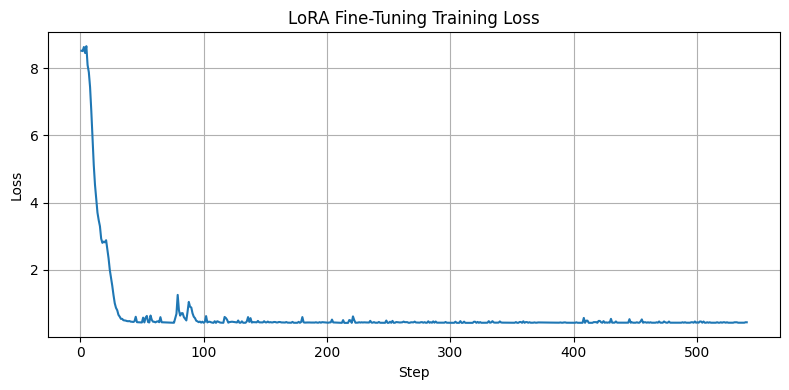

# **Questions to answer:**

1. Report the settings you used to get the best model.
  
2. Which hyperparameters did you find have the most impact in the model’s performance?

3. Why do you think that is?


**Answer:**

Loss converges to around **0.46**.

1. Best Settings
```
LORA_R = 16
LORA_ALPHA = 32
LORA_TARGET = ["q_proj", "k_proj", "v_proj", "o_proj"]

NUM_EPOCHS = 5
LR = 1e-3
BSZ_PER_DEV = 4
GRAD_ACCUM = 1
EVAL_SPLIT = 0.1
```

2. Most Impactful Hyperparameters

- LORA_TARGET: applying LoRA to all attention projections improves performance, Other LoRA params (R, alpha): little impact (loss ~0.46)
- EPCH and LR can only affect the convergence speed.

3. Why

- Attention layers are core to model behavior → adapting all projections is most effective

- Rank/scaling mainly affect efficiency, not capacity


# Problem 6: Post-Training Evaluation (30 points)

# Problem 6.1 Load the Trained LoRA Adapter

Once your fine-tuning is complete, load the trained **LoRA adapters** back onto the original model to perform inference, that is, to generate predictions or analyze new images.

Simply run the code in the next code block.  
It will automatically attach your fine-tuned LoRA weights and prepare the model for evaluation.


In [ ]:

# --------------------
# Inference with adapters
# --------------------
from peft import PeftModel
base = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    # device_map="cuda:0",
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)
ft_model = PeftModel.from_pretrained(base, OUTPUT_DIR)
ft_model.eval()
print("LoRA adapters loaded. Ready for inference.")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

LoRA adapters loaded. Ready for inference.


# Problem 6.2 Re-Test on Held-Out Images

Re-test the same **held-out images** used in your baseline evaluation.

Compare the **pre-trained** (in Step 2.2) and **fine-tuned** model outputs:

- Which questions showed improvement?  
- Did LoRA fine-tuning correct any earlier mistakes?  
- Were any new errors or biases introduced after fine-tuning?

Document your observations and include examples where possible.


Image:


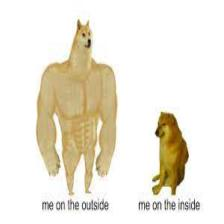

Model Output: system
You are a helpful assistant.
user
What is the communicative intention of this meme? Answer with exactly one word from: Interactive, Expressive, Entertaining, Offensive, Other.
assistant
Expressive


In [ ]:
from IPython.display import display
import PIL.Image

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
TEST_IMAGE: str = "https://www.dropbox.com/scl/fi/pd0n9508q579pvyfujskr/meme_sample_image.jpg?rlkey=zq4uonuuv5iv4t2v2ri28meed&raw=1"
TEST_QUESTION: str = "What is the communicative intention of this meme? Answer with exactly one word from: Interactive, Expressive, Entertaining, Offensive, Other."
MAX_NEW_TOKENS: int = 128
# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

# Load image
loaded_img = load_image_from_url(TEST_IMAGE)

# Display image
print("Image:")
display(loaded_img)

# Prepare messages
messages = [{"role": "user", "content": [
    {"type": "image", "image": loaded_img},
    {"type": "text", "text": TEST_QUESTION}
]}]

# Encode and generate
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = processor(text=[text], images=[loaded_img], return_tensors="pt").to(ft_model.device)

with torch.no_grad():
    out_ids = ft_model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)

# Decode output
output_text = processor.batch_decode(out_ids, skip_special_tokens=True)[0]
print("Model Output:", output_text)


# Problem 7: Final Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. What concept did you find the most interesting?
2. Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.
3. Is there a topic that was discussed during lectures up to the release of the assignment that you wished was covered in the homework? Any from the assignment that you wanted there to be touched upon more?

**Answer**

1. Most Interesting Concept
- LoRA: efficient and practical for fine-tuning; I had only used it in image generation before.

2. Usefulness for My Goals
- Fine-tuning is directly relevant to our project; LoRA enables efficient adaptation with limited resources.

3. Topics to Expand
- More on VAE and diffusion implementation
- handling time-series data.